In [1]:
import torch
import numpy as np
from model_files.SSD_from_scratch import mySSD as newSSD
from model_files.view_preds import show_prediction_side_by_side
from pathlib import Path
from torch.profiler import profile, ProfilerActivity, record_function
from typing import Callable, List, Tuple, Dict, Any, Sequence, Union, Optional, Iterable
import cv2
from dataclasses import dataclass
import time
from __future__ import annotations

import sys
sys.path.append("..")
from v1.SSD_from_scratch import mySSD as oldSSD
from benchmarking.gpu_bench import bench_inference_gpu, print_report

# desktop, laptop, ubuntu
machine = 'ubuntu'

# Setup path to data folder
if machine == 'laptop':
    folder_path = Path(r"C:\self-driving-car\data")
elif machine == 'desktop':
    folder_path = Path(r"C:\Udacity_car_data\data")
elif machine == 'ubuntu':
    folder_path = Path(r"/mnt/c/Udacity_car_data/data")

train_path = folder_path / "train"
test_path = folder_path / "test"

In [2]:
# load PyTorch old SSD model
old_ssd = oldSSD(class_to_idx_dict={'biker': 0, 'car': 1, 'pedestrian': 2, 'trafficLight': 3, 'truck': 4},
                          in_channels=3,
                          variances=(0.1, 0.2))
WEIGHTS_PATH = r"/mnt/c/Users/eblac/Documents/GitHub/self-driving-car/app_files/saved_models/noZoomOut_Bootstrap.pth"
# WEIGHTS_PATH = r"C:\Users\eblac\Documents\GitHub\self-driving-car\app_files\saved_models\noZoomOut_Bootstrap.pth"
# WEIGHTS_PATH = r"C:\Users\eblac\OneDrive\Documents\GitHub\self-driving-car\app_files\saved_models\noZoomOut_Bootstrap.pth"
state_dict = torch.load(WEIGHTS_PATH, map_location="cpu", weights_only=False)
old_ssd.load_state_dict(state_dict, strict=False)
# old_ssd.to(device='cuda');

<All keys matched successfully>

In [11]:
# load PyTorch new SSD model
new_ssd = newSSD(class_to_idx_dict={'biker': 0, 'car': 1, 'pedestrian': 2, 'trafficLight': 3, 'truck': 4},
                          in_channels=3,
                          variances=(0.1, 0.2))
WEIGHTS_PATH = Path.home() / "repos" / "automotive-ssd-object-detection" / "v2" / "saved_models" / "DIoU_mAP_551_iou_thresh_45_max_img_per_det_200.pth"
state_dict = torch.load(WEIGHTS_PATH, map_location="cpu", weights_only=False)
new_ssd.load_state_dict(state_dict, strict=False)
# new_ssd.to(device='cuda');

<All keys matched successfully>

In [13]:
# List containing test images
test_list = list(Path(test_path).glob("*.jpg"))

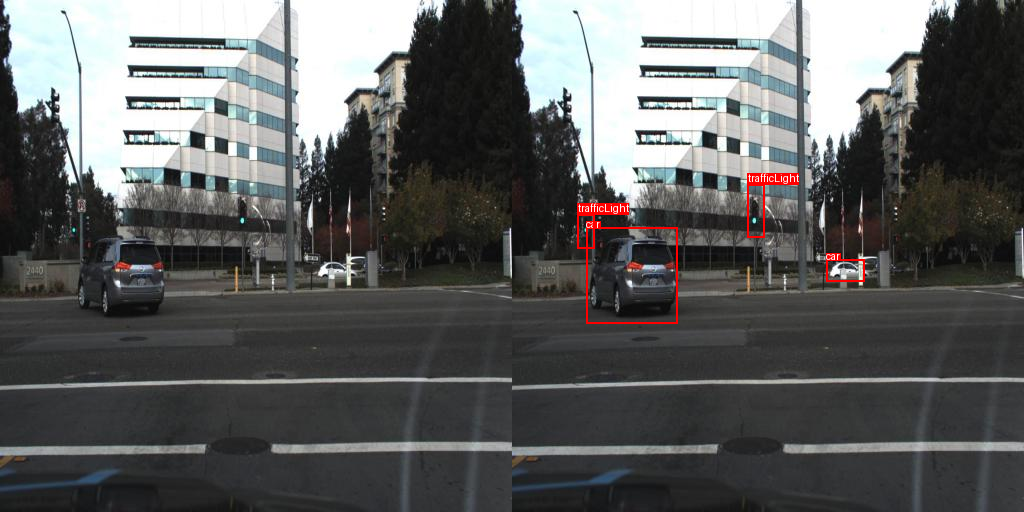

In [17]:
# View some predictions
rand_idx = np.random.randint(0, len(test_list))

old_ssd.show_prediction_side_by_side(image_path=test_list[rand_idx],
                                       pil_img=None,
                                       score_thresh=0.2,
                                       nms_thresh=0.3,
                                       max_per_img=200,
                                       class_agnostic=False,
                                       target_height=512)

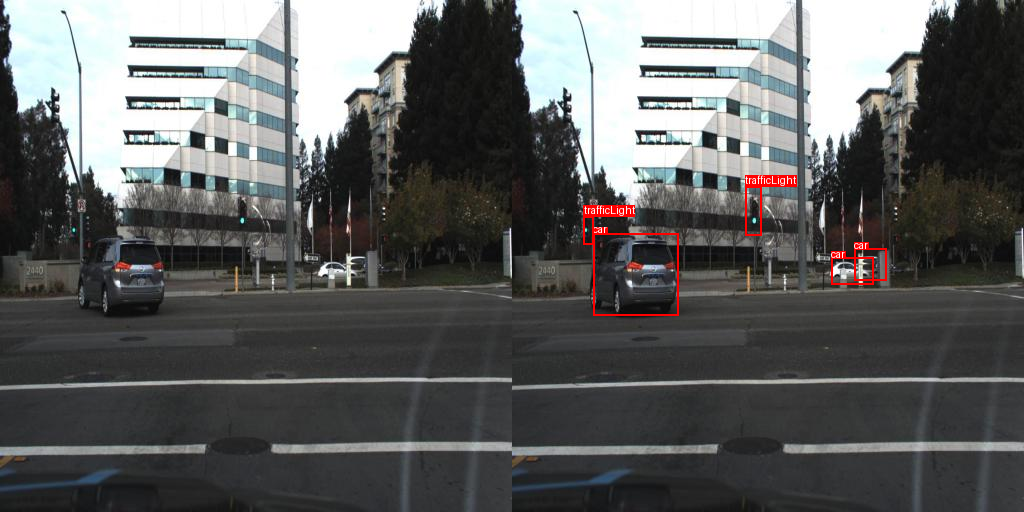

In [18]:
show_prediction_side_by_side(model=new_ssd,
                             image_path=test_list[rand_idx],
                                       pil_img=None,
                                       score_thresh=0.2,
                                       nms_thresh=0.3,
                                       max_per_img=200,
                                       class_agnostic=False,
                                       target_height=512)

In [19]:
# for loading images

def load_images_uint8_chw(
    folder: str,
    *,
    exts=(".jpg", ".jpeg", ".png"),
    limit: int | None = None,
    convert_to_rgb: bool = False,   # keep False if your preprocessing expects BGR
) -> list[np.ndarray]:
    folder = Path(folder)
    paths = sorted([p for p in folder.iterdir() if p.suffix.lower() in exts])
    if limit is not None:
        paths = paths[:limit]

    imgs: list[np.ndarray] = []
    for p in paths:
        im = cv2.imread(str(p), cv2.IMREAD_COLOR)  # uint8 HWC, BGR
        if im is None:
            raise ValueError(f"Failed to read: {p}")
        if convert_to_rgb:
            im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
        # enforce contiguous memory (avoids occasional stride surprises)
        im = np.ascontiguousarray(np.transpose(im, (2, 0, 1)))
        imgs.append(im)

    if not imgs:
        raise ValueError(f"No images found in {folder} with extensions {exts}")
    return imgs

# preprocessing function

def preprocess_uint8_chw_rgb(
    x_chw: Union[np.ndarray, torch.Tensor],
    *,
    out_size: Tuple[int, int] = (300, 300),
    mean: Sequence[float] = (0.485, 0.456, 0.406),
    std: Sequence[float]  = (0.229, 0.224, 0.225),
) -> torch.Tensor:
    """
    Input:
        x_chw: uint8 (C,H,W), RGB, values in [0,255]
    Output:
        torch.float32 (1,C,out_H,out_W)

    Equivalent to:
        v2.ToImage()
        v2.ToDtype(torch.float32, scale=True)
        v2.Resize((300,300), antialias=True)
        v2.Normalize(mean=..., std=...)
    """
    # Convert to torch.Tensor
    if isinstance(x_chw, np.ndarray):
        x = torch.from_numpy(x_chw)
    elif isinstance(x_chw, torch.Tensor):
        x = x_chw
    else:
        raise TypeError(f"Expected numpy.ndarray or torch.Tensor, got {type(x_chw)}")

    if x.ndim != 3:
        raise ValueError(f"Expected shape (C,H,W), got {tuple(x.shape)}")
    if x.dtype != torch.uint8:
        raise TypeError(f"Expected dtype uint8, got {x.dtype}")

    # ToDtype(float32, scale=True) for uint8 => /255
    x = x.to(torch.float32) / 255.0

    # Add batch dim: (1,C,H,W)
    x = x.unsqueeze(0)

    # Resize to (300,300) with antialiasing (bilinear like torchvision for tensors)
    try:
        x = torch.nn.functional.interpolate(x, size=out_size, mode="bilinear", align_corners=False, antialias=True)
    except TypeError:
        # Fallback if antialias not supported in your PyTorch version
        x = torch.nn.functional.interpolate(x, size=out_size, mode="bilinear", align_corners=False)

    # Normalize
    mean_t = torch.tensor(mean, dtype=torch.float32, device=x.device).view(1, -1, 1, 1)
    std_t  = torch.tensor(std,  dtype=torch.float32, device=x.device).view(1, -1, 1, 1)
    x = (x - mean_t) / std_t

    return x

In [20]:
# load images
img_list = np.array(load_images_uint8_chw(folder=test_path, convert_to_rgb=True, limit=1000))

In [10]:
with torch.inference_mode():
    with profile(activities=[ProfilerActivity.CPU], record_shapes=True, profile_memory=True) as prof:
        for _ in range(50):
            mi = preprocess_uint8_chw_rgb(img_list[0])
            loc_all, conf_all = old_ssd(mi)
            _ = old_ssd.predict(mi, score_thresh=0.2, nms_thresh=0.3, max_per_img=100, pre_loc_all=loc_all, pre_conf_all=conf_all)

print(prof.key_averages().table(sort_by="self_cpu_time_total", row_limit=25))

/home/eblackstone/repos/ssd-venv/lib/python3.12/site-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


---------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                             Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem    # of Calls  
---------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
         aten::mkldnn_convolution        84.15%        6.821s        84.44%        6.846s       5.705ms       4.72 GB           0 B          1200  
          aten::native_batch_norm         5.29%     428.568ms         5.39%     437.162ms     437.162us       4.71 GB      -2.90 MB          1000  
    aten::max_pool2d_with_indices         4.16%     337.027ms         4.16%     337.027ms       1.685ms       1.52 GB       1.52 GB           200  
                 aten::clamp_min_         2.78%     225.200ms         2.78%     225.200ms     204.727us         

In [6]:
with torch.inference_mode():
    with profile(activities=[ProfilerActivity.CPU], record_shapes=True, profile_memory=True) as prof:
        for _ in range(50):
            mi = preprocess_uint8_chw_rgb(img_list[0])
            loc_all, conf_all = new_ssd(mi)
            _ = new_ssd.predict(mi, score_thresh=0.2, nms_thresh=0.3, iou_variant="DIoU", max_per_img=200, pre_loc_all=loc_all, pre_conf_all=conf_all)

print(prof.key_averages().table(sort_by="self_cpu_time_total", row_limit=25))

/home/eblackstone/repos/ssd-venv/lib/python3.12/site-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


---------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                             Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem    # of Calls  
---------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
         aten::mkldnn_convolution        81.18%        7.202s        81.44%        7.225s       6.021ms       4.72 GB           0 B          1200  
          aten::native_batch_norm         8.77%     777.724ms         8.91%     790.572ms     790.572us       4.71 GB      -5.37 MB          1000  
    aten::max_pool2d_with_indices         3.99%     353.805ms         3.99%     353.805ms       1.769ms       1.52 GB       1.52 GB           200  
                 aten::clamp_min_         2.93%     259.524ms         2.93%     259.524ms     235.931us         

In [21]:
old_ssd.to(device='cuda')

with torch.inference_mode():
    with profile(activities=[ProfilerActivity.CUDA], record_shapes=True, profile_memory=True) as prof:
        for _ in range(50):
            mi = preprocess_uint8_chw_rgb(img_list[0]).to(device='cuda')
            loc_all, conf_all = old_ssd(mi)
            _ = old_ssd.predict(mi, score_thresh=0.2, nms_thresh=0.3, max_per_img=100, pre_loc_all=loc_all, pre_conf_all=conf_all)

print(prof.key_averages().table(sort_by="self_cuda_time_total", row_limit=25))

[W408 17:00:08.341237596 collection.cpp:1024] Warning: Failed to recover relationship between all profiler and kineto events: 31200 vs. 0  reassociated. (function reassociate)


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
sm86_xmma_fprop_implicit_gemm_tf32f32_tf32f32_f32_nh...         0.00%       0.000us         0.00%       0.000us       0.000us     109.045ms        19.55%     109.045ms     445.083us           0 B           0 B           0 B           0 

In [22]:
new_ssd.to(device='cuda')

with torch.inference_mode():
    with profile(activities=[ProfilerActivity.CUDA], record_shapes=True, profile_memory=True) as prof:
        for _ in range(50):
            mi = preprocess_uint8_chw_rgb(img_list[0]).to(device='cuda')
            loc_all, conf_all = new_ssd(mi)
            _ = new_ssd.predict(mi, score_thresh=0.2, nms_thresh=0.3, iou_variant="DIoU", max_per_img=200, pre_loc_all=loc_all, pre_conf_all=conf_all)

print(prof.key_averages().table(sort_by="self_cuda_time_total", row_limit=25))

[W408 17:00:16.862580105 collection.cpp:1024] Warning: Failed to recover relationship between all profiler and kineto events: 28800 vs. 0  reassociated. (function reassociate)
[W408 17:00:16.929759079 collection.cpp:665] Warning: gen_nms::ops::(anonymous namespace)::gather_keep_from_mask(bool*, unsigned long long const*, int) (function operator())


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
sm86_xmma_fprop_implicit_gemm_tf32f32_tf32f32_f32_nh...         0.00%       0.000us         0.00%       0.000us       0.000us      94.397ms        22.38%      94.397ms     385.295us           0 B           0 B           245  
void cutlass__5x_cudnn::Kernel<cutlass_tensorop_s168...         0.00%       0.000us         0.0

In [ ]:
def _ms(ns: int) -> float:
    return ns / 1e6

def _pct(sorted_vals: List[float], p: float) -> float:
    # p in [0,100]
    if not sorted_vals:
        return float("nan")
    k = (len(sorted_vals) - 1) * (p / 100.0)
    f = int(k)
    c = min(f + 1, len(sorted_vals) - 1)
    if f == c:
        return sorted_vals[f]
    return sorted_vals[f] + (k - f) * (sorted_vals[c] - sorted_vals[f])

@dataclass
class StageStats:
    n: int
    mean_ms: float
    median_ms: float
    p90_ms: float
    p95_ms: float
    p99_ms: float
    min_ms: float
    max_ms: float

def summarize(times_ms: List[float]) -> StageStats:
    s = sorted(times_ms)
    return StageStats(
        n=len(s),
        mean_ms=sum(s) / len(s),
        median_ms=_pct(s, 50),
        p90_ms=_pct(s, 90),
        p95_ms=_pct(s, 95),
        p99_ms=_pct(s, 99),
        min_ms=s[0],
        max_ms=s[-1],
    )

def bench_inference(
    inputs: Iterable[Any],
    preprocess: Callable[[Any], Any],
    model: oldSSD | newSSD,
    warmup_iters: int = 20,
    measure_iters: int = 200,
) -> Dict[str, StageStats]:
    """
    CPU-only stage timing with warmup + per-iteration latency distributions.

    inputs: iterable of already-in-memory inputs (e.g., numpy arrays or decoded images)
    preprocess: input -> model_input
    model(x): model_input -> raw_output
    model.predict(x): raw_output -> final_output
    """
    inputs = list(inputs)
    if not inputs:
        raise ValueError("inputs must be non-empty (and already in memory).")

    # --- Warmup (stabilizes caches, allocators, thread pools) ---
    wi = 0
    while wi < warmup_iters:
        x = inputs[wi % len(inputs)]
        mi = preprocess(x)
        loc_all, conf_all = model(mi) # forward(mi)
        if type(model) == oldSSD:
            _ = model.predict(mi, score_thresh=0.2, nms_thresh=0.3, max_per_img=100, pre_loc_all=loc_all, pre_conf_all=conf_all) # postprocess(ro)
        if type(model) == newSSD:
            _ = model.predict(mi, score_thresh=0.2, nms_thresh=0.3, iou_variant="DIoU", max_per_img=100, pre_loc_all=loc_all, pre_conf_all=conf_all) # postprocess(ro)
        wi += 1

    pre_t, fwd_t, post_t, e2e_t = [], [], [], []

    # --- Measure ---
    for i in range(measure_iters):
        x = inputs[i % len(inputs)]

        t0 = time.perf_counter_ns()
        mi = preprocess(x)
        t1 = time.perf_counter_ns()
        loc_all, conf_all = model(mi) # forward(mi)
        t2 = time.perf_counter_ns()
        if type(model) == oldSSD:
            _ = model.predict(mi, score_thresh=0.2, nms_thresh=0.3, max_per_img=100, pre_loc_all=loc_all, pre_conf_all=conf_all) # postprocess(ro)
        if type(model) == newSSD:
            _ = model.predict(mi, score_thresh=0.2, nms_thresh=0.3, iou_variant="DIoU", max_per_img=100, pre_loc_all=loc_all, pre_conf_all=conf_all) # postprocess(ro)
        t3 = time.perf_counter_ns()

        pre_t.append(_ms(t1 - t0))
        fwd_t.append(_ms(t2 - t1))
        post_t.append(_ms(t3 - t2))
        e2e_t.append(_ms(t3 - t0))

    out = {
        "preprocess": summarize(pre_t),
        "forward": summarize(fwd_t),
        "postprocess": summarize(post_t),
        "end_to_end": summarize(e2e_t),
    }

    # Sanity check: end_to_end should roughly equal sum of stages
    # If not, you probably have hidden work outside the stage calls (or timing overhead dominates).
    sum_means = out["preprocess"].mean_ms + out["forward"].mean_ms + out["postprocess"].mean_ms
    if abs(out["end_to_end"].mean_ms - sum_means) / max(out["end_to_end"].mean_ms, 1e-9) > 0.05:
        print(f"[warn] end_to_end mean ({out['end_to_end'].mean_ms:.3f} ms) != sum of means ({sum_means:.3f} ms).")
        print("       This usually indicates hidden work, extra copies, or stage boundary leakage.")

    return out

In [24]:
print("---------- New model: GPU ----------")
print_report(bench_inference_gpu(inputs=img_list,
                                 preprocess=preprocess_uint8_chw_rgb,
                                 model=new_ssd,
                                 warmup_iters=30,
                                 measure_iters=500,
                                 device='cuda',
                                 pin_memory=False,
                                 score_thresh=0.2,
                                 nms_thresh=0.3,
                                 new_model=True,
                                 max_per_img=100))
print()

print("---------- Old model: GPU ----------")
print_report(bench_inference_gpu(inputs=img_list,
                                 preprocess=preprocess_uint8_chw_rgb,
                                 model=old_ssd,
                                 warmup_iters=30,
                                 measure_iters=500,
                                 device='cuda',
                                 pin_memory=False,
                                 score_thresh=0.2,
                                 nms_thresh=0.3,
                                 new_model=False,
                                 max_per_img=100))

---------- New model: GPU ----------
 preprocess: n= 500  mean=   1.069  p50=   1.071  p95=   1.391  p99=   1.535  min=   0.845  max=   1.614
        h2d: n= 500  mean=   0.347  p50=   0.329  p95=   0.457  p99=   0.497  min=   0.283  max=   0.759
    forward: n= 500  mean=   9.234  p50=   8.812  p95=  13.542  p99=  15.251  min=   8.427  max=  17.600
postprocess: n= 500  mean=   2.905  p50=   2.556  p95=   6.152  p99=   7.315  min=   0.518  max=  10.230
 end_to_end: n= 500  mean=  13.555  p50=  12.801  p95=  21.177  p99=  25.676  min=  10.479  max=  26.816

---------- Old model: GPU ----------
 preprocess: n= 500  mean=   1.076  p50=   0.999  p95=   1.385  p99=   1.532  min=   0.890  max=   3.217
        h2d: n= 500  mean=   0.358  p50=   0.342  p95=   0.455  p99=   0.536  min=   0.296  max=   0.601
    forward: n= 500  mean=   9.154  p50=   8.837  p95=  11.204  p99=  13.976  min=   8.388  max=  16.406
postprocess: n= 500  mean=  12.981  p50=  10.199  p95=  28.712  p99=  55.435  min=   

In [10]:
print("---------- New model: CPU ----------")
print_report(bench_inference(inputs=img_list, preprocess=preprocess_uint8_chw_rgb, model=new_ssd, warmup_iters=30, measure_iters=500))
print()

print("---------- Old model: CPU ----------")
print_report(bench_inference(inputs=img_list, preprocess=preprocess_uint8_chw_rgb, model=old_ssd, warmup_iters=30, measure_iters=500))

---------- New model: CPU ----------
 preprocess: n= 500  mean=   1.198  p50=   1.198  p95=   1.370  p99=   1.556  min=   0.850  max=   1.778
    forward: n= 500  mean= 193.623  p50= 196.653  p95= 204.656  p99= 210.635  min= 153.813  max= 222.669
postprocess: n= 500  mean=   1.023  p50=   1.016  p95=   1.203  p99=   1.297  min=   0.751  max=   1.856
 end_to_end: n= 500  mean= 195.845  p50= 198.928  p95= 207.001  p99= 212.856  min= 155.873  max= 225.507

---------- Old model: CPU ----------
 preprocess: n= 500  mean=   1.237  p50=   1.227  p95=   1.422  p99=   1.510  min=   0.817  max=   1.642
    forward: n= 500  mean= 191.889  p50= 192.393  p95= 199.895  p99= 206.667  min= 140.025  max= 221.922
postprocess: n= 500  mean=   3.934  p50=   3.498  p95=   7.230  p99=   8.697  min=   0.958  max=   9.322
 end_to_end: n= 500  mean= 197.060  p50= 197.386  p95= 205.943  p99= 213.030  min= 143.992  max= 228.698
